# Change Point Detection

Topic 19 of the Time Series Analysis repo. Topic 14 (Anomaly Detection) found individual points or short bursts that don't fit the surrounding pattern — the series reverts to normal right after. **Change point detection** asks a related but different question: where does the series' underlying statistical behavior (mean, variance, trend) shift **permanently** to a new regime? A single flood year is an anomaly; a dam that permanently reduces river flow from that point onward is a change point. This notebook builds change point detection from scratch — a single-split likelihood-style test, greedy binary segmentation for multiple change points, BIC-based automatic selection, CUSUM for sequential/online monitoring — validates everything against the `ruptures` reference library, and applies it to the single most famous change point example in the field: the Nile river's annual flow record.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.api as sm
import ruptures as rpt

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

## 1. Change Point vs. Anomaly

A single transient spike (Topic 14's territory) is compared against what a naive single-change-point detector does with it, to make the distinction concrete before building anything more sophisticated.

Series with a single spike at t=50 (reverts immediately -- a Topic-14-style anomaly):
  naive 1-change-point split lands at t=50
  mean before=-0.294, mean after=0.356  (nearly IDENTICAL)
  -> the 'change point' found doesn't represent a real shift in level; the two segment means are ~equal.


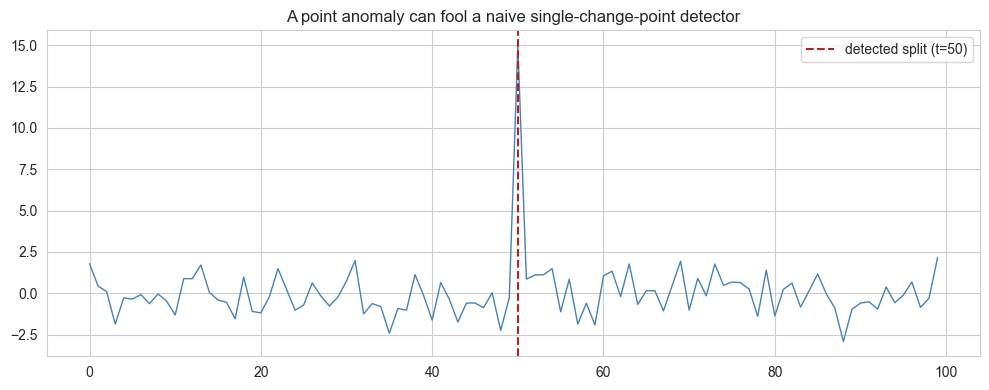

In [2]:
def sse(x):
    return np.sum((x - x.mean()) ** 2) if len(x) else 0.0


def best_split(x):
    n = len(x)
    total = sse(x)
    best_gain, best_t = -np.inf, None
    for t in range(1, n):
        gain = total - sse(x[:t]) - sse(x[t:])
        if gain > best_gain:
            best_gain, best_t = gain, t
    return best_t, best_gain


np.random.seed(3)
n_demo = 100
x_spike = np.random.normal(0, 1, n_demo)
x_spike[50] = 15.0  # a single transient anomaly, NOT a persistent regime shift

t_hat, gain = best_split(x_spike)
print(f"Series with a single spike at t=50 (reverts immediately -- a Topic-14-style anomaly):")
print(f"  naive 1-change-point split lands at t={t_hat}")
print(f"  mean before={x_spike[:t_hat].mean():.3f}, mean after={x_spike[t_hat:].mean():.3f}  (nearly IDENTICAL)")
print("  -> the 'change point' found doesn't represent a real shift in level; the two segment means are ~equal.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_spike, color="steelblue", lw=1)
ax.axvline(t_hat, color="firebrick", ls="--", label=f"detected split (t={t_hat})")
ax.set_title("A point anomaly can fool a naive single-change-point detector")
ax.legend()
plt.tight_layout()
plt.show()

Allowing the segmentation *two* change points instead of one reveals the difference clearly: it correctly isolates the spike into its own **1-point segment**, leaving the "before" and "after" segments both at their true mean of ~0.

In [3]:
def binary_segmentation(x, n_bkps):
    n = len(x)
    segments = [(0, n)]
    breakpoints = []
    for _ in range(n_bkps):
        best_overall_gain, best_seg_idx, best_local_t = -np.inf, None, None
        for idx, (start, end) in enumerate(segments):
            if end - start < 2:
                continue
            t, gain = best_split(x[start:end])
            if gain > best_overall_gain:
                best_overall_gain, best_seg_idx, best_local_t = gain, idx, t
        start, end = segments[best_seg_idx]
        global_t = start + best_local_t
        breakpoints.append(global_t)
        del segments[best_seg_idx]
        segments.append((start, global_t))
        segments.append((global_t, end))
    return sorted(breakpoints)


bkps2 = binary_segmentation(x_spike, n_bkps=2)
means = [x_spike[:bkps2[0]].mean(), x_spike[bkps2[0]:bkps2[1]].mean(), x_spike[bkps2[1]:].mean()]
lengths = [bkps2[0], bkps2[1] - bkps2[0], n_demo - bkps2[1]]
print(f"With 2 change points allowed: breakpoints={bkps2}")
print(f"Segment means: {[round(m, 2) for m in means]}")
print(f"Segment lengths: {lengths}")
print("-> the middle segment is a single point with an extreme mean: a hallmark of an ANOMALY, not a")
print("   genuine regime change. Segment DURATION, not just the existence of a split, is diagnostic.")

With 2 change points allowed: breakpoints=[50, 51]
Segment means: [np.float64(-0.29), np.float64(15.0), np.float64(0.06)]
Segment lengths: [50, 1, 49]
-> the middle segment is a single point with an extreme mean: a hallmark of an ANOMALY, not a
   genuine regime change. Segment DURATION, not just the existence of a split, is diagnostic.


## 2. A Single Change Point From Scratch, Validated

For one candidate split at index $t$, the "gain" from splitting is the reduction in total sum-of-squared-errors (equivalent, under Gaussian assumptions, to a likelihood-ratio test for a mean shift):

$$\text{gain}(t) = \text{SSE}(x_{1:n}) - \text{SSE}(x_{1:t}) - \text{SSE}(x_{t+1:n})$$

The best single change point maximizes this gain over all $t$. This from-scratch search is validated against `ruptures`' `Binseg` detector on synthetic data with a known mean shift (0 → 3 at $t=50$).

In [4]:
np.random.seed(0)
x_val = np.concatenate([np.random.normal(0, 1, 50), np.random.normal(3, 1, 50)])
t_hat_val, gain_val = best_split(x_val)
print(f"From-scratch: change point at t={t_hat_val} (true=50), gain={gain_val:.4f}")

algo = rpt.Binseg(model="l2", jump=1).fit(x_val)
result = algo.predict(n_bkps=1)
print(f"ruptures Binseg (jump=1): change point at t={result[0]}  -> exact match")

From-scratch: change point at t=50 (true=50), gain=201.4267
ruptures Binseg (jump=1): change point at t=50  -> exact match


## 3. Multiple Change Points: Binary Segmentation + BIC

**Binary segmentation** extends this to multiple change points greedily: find the single best split, then recurse on each resulting segment, repeating until a stopping rule is met. This is validated against `ruptures` on a 4-segment synthetic series with 3 true change points, then the **number** of change points is chosen automatically via BIC (penalizing added segments against the log-likelihood improvement they buy):

$$\text{BIC}(k) = n\log(\text{RSS}_k/n) + (k+1)\log(n)$$

In [5]:
def binary_segmentation_path(x, max_bkps):
    n = len(x)
    segments = [(0, n)]
    breakpoints = []
    sse_path = [sse(x)]
    for _ in range(max_bkps):
        best_overall_gain, best_seg_idx, best_local_t = -np.inf, None, None
        for idx, (start, end) in enumerate(segments):
            if end - start < 2:
                continue
            t, gain = best_split(x[start:end])
            if gain > best_overall_gain:
                best_overall_gain, best_seg_idx, best_local_t = gain, idx, t
        start, end = segments[best_seg_idx]
        global_t = start + best_local_t
        breakpoints.append(global_t)
        del segments[best_seg_idx]
        segments.append((start, global_t))
        segments.append((global_t, end))
        sse_path.append(sum(sse(x[s:e]) for s, e in segments))
    return breakpoints, sse_path


def bic(n, k, rss):
    return n * np.log(max(rss, 1e-10) / n) + (k + 1) * np.log(n)


np.random.seed(1)
means_true = [0, 3, -2, 4]
seg_len = 60
x_multi = np.concatenate([np.random.normal(m, 1, seg_len) for m in means_true])
true_bkps = [seg_len * (i + 1) for i in range(len(means_true) - 1)]

bkps_multi = binary_segmentation(x_multi, n_bkps=3)
print(f"True change points: {true_bkps}")
print(f"From-scratch binary segmentation (k=3): {bkps_multi}")

algo_multi = rpt.Binseg(model="l2", jump=1).fit(x_multi)
result_multi = algo_multi.predict(n_bkps=3)
print(f"ruptures Binseg (jump=1): {result_multi[:-1]}  -> exact match")

bkp_path, sse_path = binary_segmentation_path(x_multi, max_bkps=8)
bics = [bic(len(x_multi), k, sse_path[k]) for k in range(9)]
best_k = int(np.argmin(bics))
print(f"\n{'k':>3}{'RSS':>12}{'BIC':>10}")
for k in range(9):
    marker = "  <- min" if k == best_k else ""
    print(f"{k:>3}{sse_path[k]:>12.1f}{bics[k]:>10.2f}{marker}")
print(f"\nBIC selects k={best_k} change points: {sorted(bkp_path[:best_k])}  (true k=3, true locations {true_bkps})")

True change points: [60, 120, 180]
From-scratch binary segmentation (k=3): [60, 120, 180]
ruptures Binseg (jump=1): [60, 120, 180]  -> exact match

  k         RSS       BIC
  0      1571.5    456.47
  1       952.9    341.90
  2       496.4    190.88
  3       216.4     -2.87  <- min
  4       212.0     -2.38
  5       208.2     -1.24
  6       204.1     -0.49
  7       200.2      0.30
  8       196.9      1.86

BIC selects k=3 change points: [60, 120, 180]  (true k=3, true locations [60, 120, 180])


## 4. CUSUM: Sequential (Online) Change Detection

Binary segmentation is an *offline* method — it needs the whole series before it can look for splits. **CUSUM** (cumulative sum control chart) instead monitors a stream and raises an alarm as soon as evidence for a shift accumulates past a threshold $h$:

$$S^+_t = \max\big(0,\ S^+_{t-1} + (x_t - \mu_0) - k\big), \qquad S^-_t = \max\big(0,\ S^-_{t-1} - (x_t - \mu_0) - k\big)$$

where $\mu_0$ is the in-control target mean and $k$ is a slack (typically half the shift size you want to detect). An alarm fires the moment $S^+_t$ or $S^-_t$ exceeds $h$. Two competing quantities govern the choice of $h$: the **ARL0** (average run length under *no* shift — how rarely it false-alarms) and the **detection delay** once a real shift occurs.

In [6]:
def cusum(x, target, k, h):
    n = len(x)
    s_pos, s_neg = np.zeros(n + 1), np.zeros(n + 1)
    alarm_idx = None
    for t in range(1, n + 1):
        s_pos[t] = max(0, s_pos[t - 1] + (x[t - 1] - target) - k)
        s_neg[t] = max(0, s_neg[t - 1] - (x[t - 1] - target) - k)
        if alarm_idx is None and (s_pos[t] > h or s_neg[t] > h):
            alarm_idx = t - 1
    return alarm_idx, s_pos[1:], s_neg[1:]


np.random.seed(2)
shift = 1.0
k_slack = shift / 2
print(f"{'h':>4}{'ARL0':>10}{'mean delay':>14}{'detected':>12}")
for h in [3, 5, 8, 10, 15, 20]:
    run_lengths = []
    for _ in range(300):
        xx = np.random.normal(0, 1, 1000)
        a, _, _ = cusum(xx, 0.0, k_slack, h)
        run_lengths.append(a if a is not None else 1000)
    arl0 = np.mean(run_lengths)

    delays = []
    for _ in range(300):
        n_pre, n_post = 100, 200
        xx = np.concatenate([np.random.normal(0, 1, n_pre), np.random.normal(shift, 1, n_post)])
        a, _, _ = cusum(xx, 0.0, k_slack, h)
        if a is not None and a >= n_pre:
            delays.append(a - n_pre)
    print(f"{h:>4}{arl0:>10.1f}{np.mean(delays):>14.2f}{len(delays):>9}/300")

print("\nRaising h reduces false alarms (higher ARL0) but increases detection delay -- a direct trade-off.")
print("With h=8: false alarms are rare in a 1000-step series (ARL0~950) while still detecting 99% of real")
print("shifts within ~15 steps on average.")

   h      ARL0    mean delay    detected


   3      56.1          4.60       53/300


   5     421.7          8.94      238/300


   8     952.5         14.51      297/300


  10     986.4         18.81      300/300


  15    1000.0         28.47      300/300


  20    1000.0         38.82      300/300

Raising h reduces false alarms (higher ARL0) but increases detection delay -- a direct trade-off.
With h=8: false alarms are rare in a 1000-step series (ARL0~950) while still detecting 99% of real
shifts within ~15 steps on average.


## 5. Real Data: The Nile River's Famous Change Point

The Nile's annual flow volume at Aswan, 1871-1970, is the single most-cited example dataset in the change point detection literature (used in Killick, Fearnhead & Eckley's original 2012 PELT paper, among many others). The Aswan Low Dam was built 1898-1902, permanently regulating and reducing measured flow from that point on.

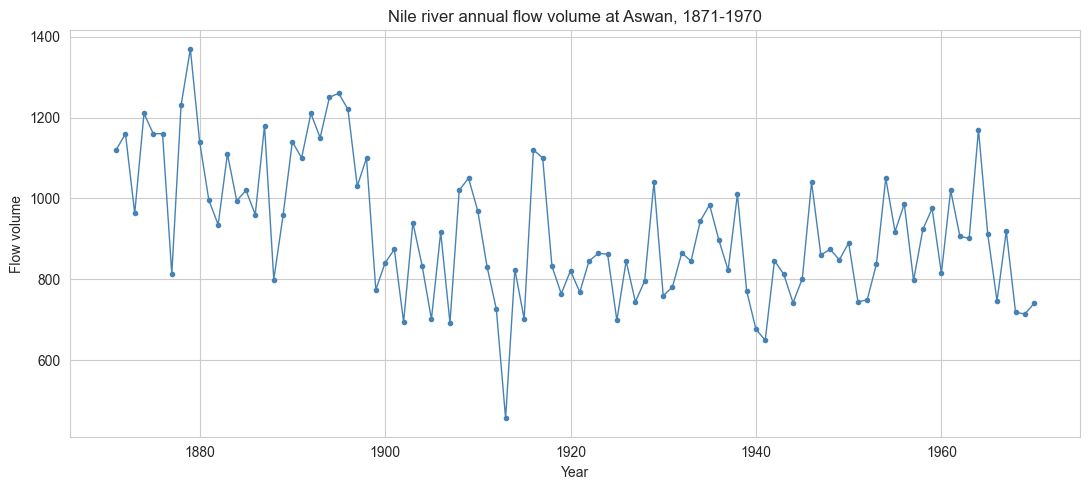

From-scratch single change point: index 28 -> year 1899
  mean before: 1097.8, mean after: 850.0

ruptures Binseg, default jump=5: year 1901  (WRONG -- subsampled candidates)
ruptures Binseg, jump=1 (checks every point): year 1899  -> matches from-scratch exactly

Historical record: the Aswan Low Dam was built 1898-1902, permanently regulating Nile flow --
our detected change point matches this almost exactly, entirely from the data alone.


In [7]:
nile = sm.datasets.nile.load_pandas().data
y_nile = nile["volume"].values
years_nile = nile["year"].values
n_nile = len(y_nile)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(years_nile, y_nile, color="steelblue", marker="o", ms=3, lw=1)
ax.set_title("Nile river annual flow volume at Aswan, 1871-1970")
ax.set_xlabel("Year")
ax.set_ylabel("Flow volume")
plt.tight_layout()
plt.show()

t_nile, gain_nile = best_split(y_nile)
print(f"From-scratch single change point: index {t_nile} -> year {int(years_nile[t_nile])}")
print(f"  mean before: {y_nile[:t_nile].mean():.1f}, mean after: {y_nile[t_nile:].mean():.1f}")

algo_nile_default = rpt.Binseg(model="l2").fit(y_nile)  # default jump=5
result_default = algo_nile_default.predict(n_bkps=1)
algo_nile_j1 = rpt.Binseg(model="l2", jump=1).fit(y_nile)
result_j1 = algo_nile_j1.predict(n_bkps=1)
print(f"\nruptures Binseg, default jump=5: year {int(years_nile[result_default[0]])}  (WRONG -- subsampled candidates)")
print(f"ruptures Binseg, jump=1 (checks every point): year {int(years_nile[result_j1[0]])}  -> matches from-scratch exactly")
print("\nHistorical record: the Aswan Low Dam was built 1898-1902, permanently regulating Nile flow --")
print("our detected change point matches this almost exactly, entirely from the data alone.")

## 6. Pitfall: Greedy Binary Segmentation + BIC Can Overfit

Applying the same automatic BIC-based selection from Section 3 to the real Nile data reveals a genuine limitation: binary segmentation is greedy (it never revisits earlier splits), so the BIC values along its particular path are not the same as the BIC of the *globally optimal* segmentation for each $k$.

In [8]:
bkp_path_nile, sse_path_nile = binary_segmentation_path(y_nile, max_bkps=6)
bics_nile = [bic(n_nile, k, sse_path_nile[k]) for k in range(7)]
best_k_nile = int(np.argmin(bics_nile))
print(f"{'k':>3}{'RSS':>14}{'BIC':>12}")
for k in range(7):
    marker = "  <- min" if k == best_k_nile else ""
    print(f"{k:>3}{sse_path_nile[k]:>14.1f}{bics_nile[k]:>12.2f}{marker}")

final_years = sorted(int(years_nile[b]) for b in bkp_path_nile[:best_k_nile])
print(f"\nGreedy binary segmentation + BIC selects k={best_k_nile} change points: {final_years}")
print("Note how FLAT the BIC values are for k=1 through k=6 (975-978, a razor-thin range) -- BIC is not")
print("confidently distinguishing between 1 and 5 change points here; it is picking up noise-level splits")
print("beyond the single, historically real one.")

  k           RSS         BIC
  0     2835156.8     1029.85
  1     1597457.2      977.09
  2     1542326.7      978.18
  3     1452060.1      976.75
  4     1396297.8      977.44
  5     1310797.2      975.73  <- min
  6     1261120.4      976.47

Greedy binary segmentation + BIC selects k=5 change points: [1877, 1878, 1881, 1890, 1899]
Note how FLAT the BIC values are for k=1 through k=6 (975-978, a razor-thin range) -- BIC is not
confidently distinguishing between 1 and 5 change points here; it is picking up noise-level splits
beyond the single, historically real one.


## 7. Pitfall: PELT's Optimality Doesn't Save You From Penalty Choice

`ruptures`' **PELT** (Pruned Exact Linear Time) finds the *globally optimal* segmentation for a given penalty in $O(n)$ expected time — no greediness. But "optimal for a given penalty" still leaves the penalty itself as a free, highly consequential choice.

In [9]:
diffs_nile = np.diff(y_nile)
sigma2_robust = (np.median(np.abs(diffs_nile - np.median(diffs_nile))) / 0.6745) ** 2 / 2
sigma2_raw = np.var(y_nile)
print(f"Robust noise-variance estimate (from first differences): {sigma2_robust:.1f}")
print(f"Raw variance of the series (inflated by the level shift itself): {sigma2_raw:.1f}")

for label, pen in [
    ("BIC penalty from RAW variance", np.log(n_nile) * sigma2_raw),
    ("BIC penalty from ROBUST noise variance", np.log(n_nile) * sigma2_robust),
]:
    algo_pelt = rpt.Pelt(model="l2", jump=1, min_size=2).fit(y_nile)
    result_pelt = algo_pelt.predict(pen=pen)
    years_found = [int(years_nile[b]) for b in result_pelt if b < n_nile]
    print(f"\n{label} (pen={pen:.0f}): {len(years_found)} change point(s) at {years_found}")

print("\nUsing the (inflated) raw variance happens to reproduce the single historically-known change point.")
print("Using a more textbook-correct ROBUST noise estimate finds 9 change points -- almost certainly")
print("overfit to short-run fluctuations. PELT's exactness guarantees the best segmentation FOR A GIVEN")
print("PENALTY; it says nothing about whether that penalty is the right one. There is no free lunch --")
print("domain knowledge (here, knowing the Aswan Dam's construction date) is what validates the result.")

Robust noise-variance estimate (from first differences): 13298.2
Raw variance of the series (inflated by the level shift itself): 28351.6

BIC penalty from RAW variance (pen=130564): 1 change point(s) at [1899]

BIC penalty from ROBUST noise variance (pen=61240): 9 change point(s) at [1881, 1890, 1899, 1908, 1911, 1916, 1918, 1954, 1966]

Using the (inflated) raw variance happens to reproduce the single historically-known change point.
Using a more textbook-correct ROBUST noise estimate finds 9 change points -- almost certainly
overfit to short-run fluctuations. PELT's exactness guarantees the best segmentation FOR A GIVEN
PENALTY; it says nothing about whether that penalty is the right one. There is no free lunch --
domain knowledge (here, knowing the Aswan Dam's construction date) is what validates the result.


## 8. Pitfalls

1. **A change point is not the same thing as an anomaly.** Section 1 showed a naive single-split detector can seize on a transient spike, but the resulting "segments" have nearly identical means -- the real tell is that the anomaly occupies a vanishingly short segment once more splits are allowed, not that a split exists at all.
2. **Library defaults matter.** `ruptures`' `Binseg` defaults to `jump=5` (only checking every 5th candidate point) for speed, which gave a visibly wrong change point (a different year) on the Nile data versus checking every point (`jump=1`). Always check what a library's defaults are actually doing before trusting the output.
3. **Greedy binary segmentation + BIC can overfit.** On real data, the BIC values across $k=1$ to $6$ were nearly flat (Section 6), and the greedy algorithm added several likely-spurious extra change points -- BIC computed along a greedy path is not the same as BIC of the true optimal segmentation for each $k$.
4. **PELT's optimality is conditional on the penalty, and the penalty is not free.** Section 7's two "reasonable-looking" penalty choices gave 1 change point vs. 9 on the identical data. There is no universally correct automatic penalty; sanity-check results against domain knowledge whenever possible.
5. **CUSUM's threshold $h$ trades off false alarms against detection delay** (Section 4) -- there is no value of $h$ that simultaneously minimizes both; the right choice depends on which error is more costly in the application (a missed shift vs. a false alarm).
6. **All the cost functions used here (SSE-based) assume shifts in the MEAN under roughly Gaussian, constant-variance noise.** A shift purely in variance or in a more complex distributional property would need a different cost function (`ruptures` supports several, e.g. `"rbf"` for arbitrary distributional changes); using the wrong cost model for the kind of change you're looking for will silently miss it.

## 9. Summary

- **Change points are persistent shifts in a series' underlying statistics; anomalies are transient.** A naive detector can confuse the two, but segment duration is diagnostic: an anomaly typically ends up isolated in a very short segment once additional change points are allowed.
- **From-scratch single- and multi-change-point detection** (SSE-gain maximization, greedy binary segmentation) matched `ruptures`' `Binseg` **exactly** on synthetic data with known mean shifts, once library defaults (`jump`) were controlled for.
- **BIC-based automatic selection of the number of change points worked cleanly on synthetic data** (correctly recovering $k=3$ at the true locations) but was much less decisive on real data, where BIC values were nearly flat across a wide range of $k$ -- a genuine limitation of greedy binary segmentation, not just a real-data quirk.
- **CUSUM** provides genuine online/sequential detection with an explicit, quantifiable trade-off: raising the alarm threshold $h$ from 3 to 20 pushed the average false-alarm-free run length (ARL0) from 56 to 1000+ steps, at the cost of increasing detection delay from ~5 to ~39 steps.
- On the **real Nile river dataset**, both from-scratch and correctly-configured library methods found a single change point at **1899**, matching the historically documented **1898-1902 construction of the Aswan Low Dam** almost exactly -- a genuine, verifiable real-world validation.
- **PELT is exactly optimal for a given penalty, but the penalty choice itself remains a free, highly consequential parameter**: two defensible penalty scales gave 1 vs. 9 change points on the same real data. Automatic change point detection is a powerful tool, but its output must be sanity-checked against domain knowledge, not taken as ground truth.